# Caustic Optimization Demo

End-to-end Python demo: construct a wave tank, set up actuators, analytically warm-start, then optimize with Adam to reproduce a target caustic pattern.

This notebook runs in the `wavetank` uv environment.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from wavetank import (
    Tank, Actuator, build_propagator,
    steady_state_amplitudes, caustic_image,
    pack_complex, unpack_complex,
    cosine_loss, load_target_image,
    Stage, optimize_caustic,
    analyze_target, analytical_solve, setup_from_target,
    feasibility_report, print_feasibility_report,
)

print(f"JAX {jax.__version__} on {jax.default_backend()}")


JAX 0.9.2 on cpu


## 1. Define tank and target

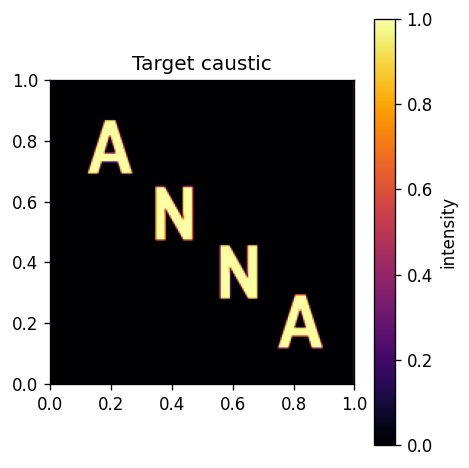

Target shape: (200, 200)


In [37]:
# Physical parameters
# projection_distance is NOT set here — throw = depth = 0.12 m.
# The feasibility report (cell 7) prints the recommended minimum throw
# for this target in mm.  If you need to set it, convert to metres first:
#   e.g. recommended 250 mm → projection_distance=0.25
tank = Tank(Lx=1.0, Ly=1.0, depth=0.12, damping=0.02, projection_distance=1.5)

nx, ny = 200, 200
xs = np.linspace(0, tank.Lx, nx)
ys = np.linspace(0, tank.Ly, ny)
XX, YY = np.meshgrid(xs, ys, indexing='ij')

# cx, cy = 0.21, 0.35
# sigma_r = 0.08
# target = np.exp(-((XX - cx)**2 + (YY - cy)**2) / (2 * sigma_r**2)).astype(np.float64)
target = load_target_image('../targets/ANNA.jpg', xs, ys)
target = target[::-1].T
target /= target.max()

plt.figure(figsize=(4, 4))
plt.imshow(target.T, origin='lower', extent=[0, tank.Lx, 0, tank.Ly], cmap='inferno')
plt.colorbar(label='intensity')
plt.title('Target caustic')
plt.tight_layout()
plt.savefig('target.png', dpi=120)
plt.show()
print(f'Target shape: {target.shape}')


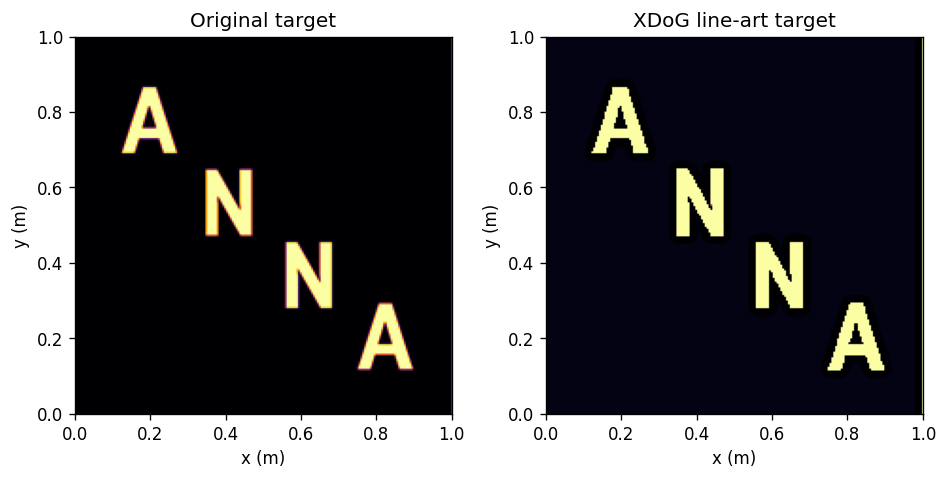

In [38]:
# XDoG preprocessing — replace the continuous-tone target with a line-art
# version that lives in the curvature-biased subspace the caustic physics
# can render. Bright lines on dark background match the caustic aesthetic
# (light adds intensity to the local image).
from scipy.ndimage import gaussian_filter

def xdog(img, sigma=0.7, k=1.6, p=20.0, eps=0.01, phi=200.0):
    g1 = gaussian_filter(img, sigma=sigma)
    g2 = gaussian_filter(img, sigma=k * sigma)
    dog = (1.0 + p) * g1 - p * g2
    return np.where(dog >= eps, 1.0, 1.0 + np.tanh(phi * (dog - eps)))

xdog_raw = xdog(target)                  # white-bg, dark-line stylization
target_line = xdog_raw             # invert → dark-bg, bright-line
target_line = np.clip(target_line, 0.0, None).astype(np.float64)
target_line /= max(target_line.max(), 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(target.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[0].set_title('Original target')
axes[1].imshow(target_line.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[1].set_title('XDoG line-art target')
for ax in axes:
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout()
plt.savefig('target_xdog.png', dpi=120)
plt.show()

# Hand the line-art target to downstream cells
target = target_line

## 2. Auto-configure: analyze target → build propagator → analytical warm-start

In [39]:
setup = setup_from_target(
    target, tank,
    nx=nx, ny=ny,
    energy_fraction=0.99,
    n_modes_max=50,
    T_eval=1.0,
)

prop       = setup['prop']
Omega_freqs = setup['Omega_freqs']
target_bl  = setup['target_bl']  # band-limited version of target
freqs      = setup['freqs']
p0         = setup['p0']

print(f"Propagator: {len(prop.omega)} modes, {prop.n_act} actuators, {len(Omega_freqs)} frequencies")
print(f"Frequencies: {freqs.round(2)} Hz")
print(f"p0 norm: {np.linalg.norm(p0):.4g}")


  Target Analysis
  Grid: 200×200
  Modes capturing 99% energy: 1223
  Highest mode indices: m_max=50, n_max=50
  Frequency range: 0.53 – 6.81 Hz
  Suggested: n_modes=51, n_freq=14, n_act=204 (51/side)
  Top 5 modes by energy:
    (5,5)  f=2.34 Hz  energy=7.9%
    (2,2)  f=1.32 Hz  energy=3.7%
    (1,1)  f=0.73 Hz  energy=3.0%
    (3,3)  f=1.75 Hz  energy=2.9%
    (4,4)  f=2.07 Hz  energy=1.9%

Setup: 204 actuators, 14 frequencies (0.53–6.81 Hz), 2600 modes
Grid: 200×200,  Parameters: 5712
  Analytical solve: 460/2600 modes achievable
  Caustic contrast 15.535 → 0.5 (scale=0.0322)
  ‖a_desired‖ = 0.002142,  ‖p0‖ = 0.0006397
Propagator: 2600 modes, 204 actuators, 14 frequencies
Frequencies: [0.53 1.01 1.5  1.98 2.46 2.95 3.43 3.91 4.39 4.88 5.36 5.84 6.33 6.81] Hz
p0 norm: 0.0006397


## 2b. Feasibility check

Before burning compute on the optimizer, predict whether the target is reproducible in the linear-wave regime. The report distinguishes two failure modes:

1. **Target itself violates linearity** — the ideal surface implied by the target already has `|η|/depth > 0.1` or `|∇η| > 0.1`. No actuator tweak helps; the target is physically impossible for this tank.
2. **Actuator subspace insufficient** — the target is fine, but the available actuators/modes/frequencies cannot reach it.


In [40]:
report = feasibility_report(prop, target_bl, Omega_freqs, T_eval=1.0)
print_feasibility_report(report)


  Analytical solve: 460/2600 modes achievable
  Caustic contrast 15.535 → 0.5 (scale=0.0322)
  ‖a_desired‖ = 0.002142,  ‖p0‖ = 0.0006397
  Feasibility report
  Warm-start cosine similarity:  0.3304
  Water depth:             120.0 mm
  Projection distance:    1500.0 mm
  Resolution limit:        112.8 mm (smallest feature in linear regime ≈ throw/13.3)
  Recommended throw:       343.3 mm (for this target to fit the linear regime)

                       desired    realized
  max|η|     (mm)        2.75        2.75
  |η|/depth             0.023       0.023
  max|∇η|               0.015       0.014
  ‖a‖                  0.0021      0.0021

  Verdict:
    [PASS] target and actuator subspace both inside the linear regime
           — ready to optimize


In [41]:
# Compute the recommended throw from the feasibility report and apply it.
# WARNING: recommended_projection_distance_m is in METRES (the report
# prints it in mm for readability — do not copy that number here).
rec_throw = report['recommended_projection_distance_m']   # metres
cur_throw = prop.tank.throw

if rec_throw > cur_throw * 1.01:
    print(f'Updating throw: {cur_throw*1000:.1f} mm → {rec_throw*1000:.1f} mm')
    tank = Tank(Lx=tank.Lx, Ly=tank.Ly, depth=tank.depth,
                damping=tank.damping, projection_distance=rec_throw)
    prop = build_propagator(tank, setup['actuators'], prop.n_modes, nx, ny)
    from wavetank.analytical import analytical_solve
    sol = analytical_solve(prop, target_bl, Omega_freqs, T_eval=1.0)
    p0 = sol['p0']
    print(f'Done. throw={rec_throw*1000:.1f} mm  ‖p0‖={np.linalg.norm(p0):.4g}')
else:
    print(f'Throw {cur_throw*1000:.1f} mm already sufficient '
          f'(recommended minimum: {rec_throw*1000:.1f} mm)')


Throw 1500.0 mm already sufficient (recommended minimum: 343.3 mm)


## 3. Evaluate analytical warm-start caustic

Analytical warm-start cosine similarity: 0.2895
Caustic range: [29.826, 113.391]  (mean=96.407 — always ~1; target range [0,1])


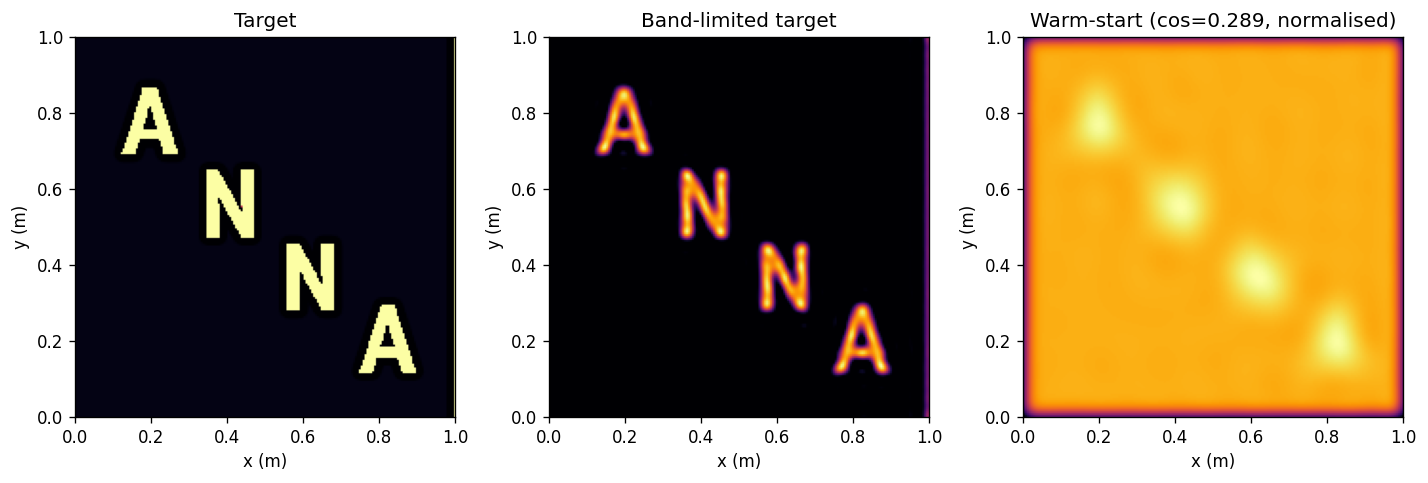

In [42]:
n_act = prop.n_act
n_freq = len(Omega_freqs)
X0, Y0 = unpack_complex(jnp.asarray(p0), n_act, n_freq)
P0 = X0 + 1j * Y0
a0 = steady_state_amplitudes(prop, P0, jnp.asarray(Omega_freqs), T=1.0)
_, _, I0 = caustic_image(prop, a0, sigma=0.02, full_snell=True)
I0_np = np.asarray(I0)

cos_sim = float(1 - cosine_loss(I0, jnp.asarray(target_bl)))
print(f'Analytical warm-start cosine similarity: {cos_sim:.4f}')
print(f'Caustic range: [{I0_np.min():.3f}, {I0_np.max():.3f}]  '
      f'(mean={I0_np.mean():.3f} — always ~1; target range [0,1])')

# Normalize I0 for display: map [min, max] -> [0, 1] so the structure
# is visible. The caustic mean is always ~1 (light is conserved), so
# raw values look like uniform gray next to the 0-1 target.
I0_disp = (I0_np - I0_np.min()) / max(I0_np.max() - I0_np.min(), 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[0].set_title('Target')
axes[1].imshow(target_bl.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[1].set_title('Band-limited target')
axes[2].imshow(I0_disp.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[2].set_title(f'Warm-start (cos={cos_sim:.3f}, normalised)')
for ax in axes:
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout()
plt.savefig('warmstart.png', dpi=120)
plt.show()


## 4. Optimize

  L-BFGS: initial loss=0.5242, running up to 150 iterations...
  L-BFGS: final loss=0.4958 after 150 iters (grad_norm=2.76e-01)
  L-BFGS: initial loss=0.5629, running up to 150 iterations...
  L-BFGS: final loss=0.5410 after 150 iters (grad_norm=5.33e+00)
  L-BFGS: initial loss=0.5622, running up to 150 iterations...
  L-BFGS: final loss=0.5408 after 150 iters (grad_norm=8.68e+00)

  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  WARNING — linear-wave assumptions violated
    max|η|     =    5.78 mm   (depth = 120.0 mm)
    |η|/depth  =   0.048    (OK)
    max|∇η|    =   0.116    (FAIL — should be < 0.1)
  Linear-wave theory and paraxial refraction are unreliable here.
  Try: increase lambda_eta, lower target intensity, or use more modes.
  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


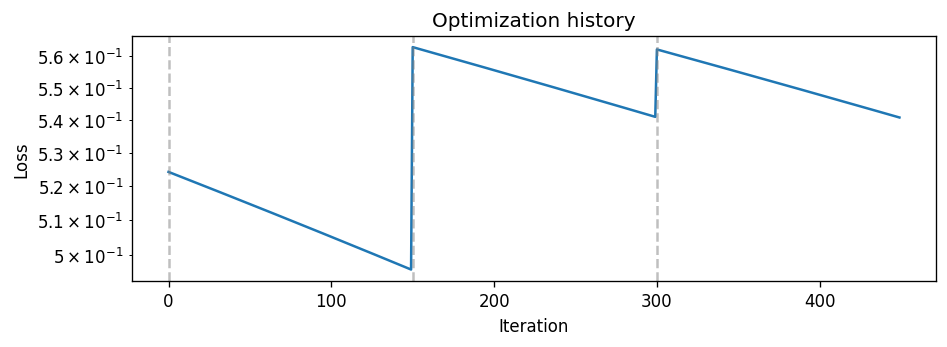

In [43]:
stages = (
    Stage(sigma=0.04, sigma_blur=0.04, iters=150, method='lbfgs'),
    Stage(sigma=0.02, sigma_blur=0.02, iters=150, method='lbfgs'),
    Stage(sigma=0.01, sigma_blur=0.01, iters=150, method='lbfgs'),
)

params_opt, loss_history = optimize_caustic(
    prop, target_bl, Omega_freqs, T_eval=1.0,
    stages=stages,
    lambda_energy=1e-6,
    loss_type='cosine',
    full_snell=True,
    p0=p0,
)

plt.figure(figsize=(8, 3))
plt.semilogy(loss_history)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('Optimization history')
for i, s in enumerate(stages):
    plt.axvline(x=sum(st.iters for st in stages[:i]), color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('loss_history.png', dpi=120)
plt.show()


## 5. Evaluate optimized result

Optimized cosine similarity: 0.5528  (warm-start: 0.2895)


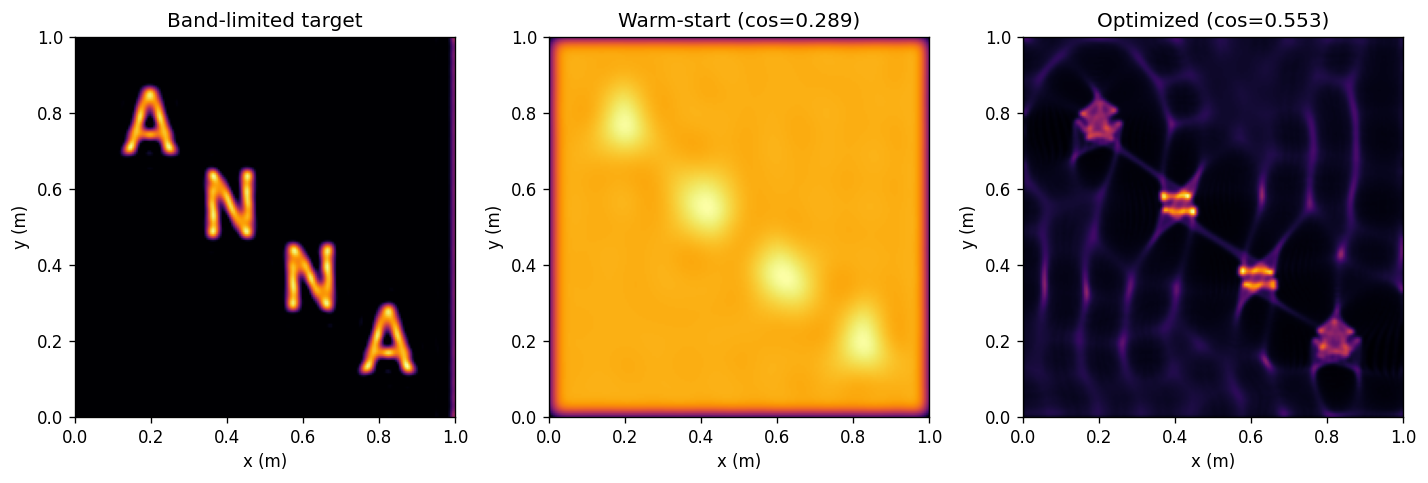

In [44]:
X_opt, Y_opt = unpack_complex(jnp.asarray(params_opt), n_act, n_freq)
P_opt = X_opt + 1j * Y_opt
a_opt = steady_state_amplitudes(prop, P_opt, jnp.asarray(Omega_freqs), T=1.0)
_, _, I_opt = caustic_image(prop, a_opt, sigma=0.005)
I_opt_np = np.asarray(I_opt)

cos_sim_opt = float(1 - cosine_loss(I_opt, jnp.asarray(target_bl)))
print(f"Optimized cosine similarity: {cos_sim_opt:.4f}  (warm-start: {cos_sim:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_bl.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[0].set_title('Band-limited target')
axes[1].imshow(I0_np.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[1].set_title(f'Warm-start (cos={cos_sim:.3f})')
axes[2].imshow(I_opt_np.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly], cmap='inferno')
axes[2].set_title(f'Optimized (cos={cos_sim_opt:.3f})')
for ax in axes:
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout()
plt.savefig('optimized.png', dpi=120)
plt.show()

## 6. Surface and actuator visualization

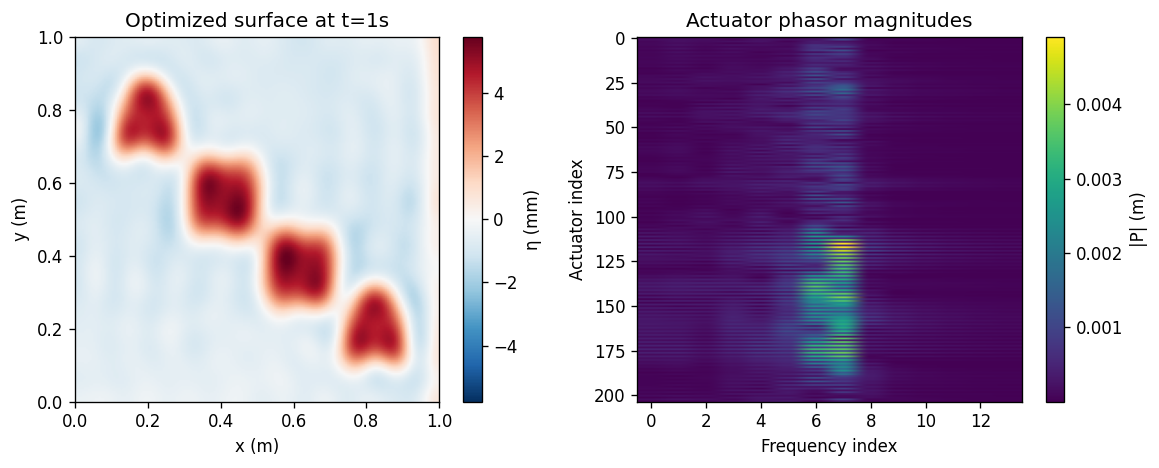

Max surface displacement: 5.78 mm
Actuator RMS amplitude: 0.602 mm


In [45]:
from wavetank import reconstruct_surface

eta_opt, _, _ = reconstruct_surface(prop, a_opt)
eta_np = np.asarray(eta_opt) * 1000  # mm

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(eta_np.T, origin='lower', extent=[0,tank.Lx,0,tank.Ly],
                    cmap='RdBu_r', vmin=-np.abs(eta_np).max(), vmax=np.abs(eta_np).max())
plt.colorbar(im, ax=axes[0], label='η (mm)')
axes[0].set_title('Optimized surface at t=1s')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')

# Actuator amplitudes at each frequency
n_act = prop.n_act
amps = jnp.sqrt(X_opt**2 + Y_opt**2)  # [n_act, n_freq]
im2 = axes[1].imshow(np.asarray(amps), aspect='auto', cmap='viridis')
plt.colorbar(im2, ax=axes[1], label='|P| (m)')
axes[1].set_title('Actuator phasor magnitudes')
axes[1].set_xlabel('Frequency index'); axes[1].set_ylabel('Actuator index')
plt.tight_layout()
plt.savefig('surface_actuators.png', dpi=120)
plt.show()

print(f"Max surface displacement: {float(jnp.abs(eta_opt).max())*1000:.2f} mm")
print(f"Actuator RMS amplitude: {float(jnp.sqrt(jnp.mean(amps**2)))*1000:.3f} mm")
